# Notebook 6: Robustness, Sensitivity, and Reproducibility

Notebook này bổ sung các yêu cầu còn thiếu cho Regression:
- Sensitivity analysis theo train/test split (60/40, 70/30, 80/20) + boxplot ổn định
- Noise injection với Gaussian noise $\sigma \in \{0.1,0.5,1.0\}$
- Feature corruption (10%, 20%, 30%) + mean/median/KNN imputation
- Convergence curves cho thuật toán lặp
- Log đầy đủ: seed, split indices, fold metrics, hyperparameters
- Báo cáo train/test time và peak memory từng model

Lưu ý: `Gaussian Process` và `Kernel Ridge` chạy full data có thể rất chậm.

In [1]:
import os
import json
import time
import tracemalloc
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge, HuberRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.kernel_approximation import RBFSampler
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer

from utils import (
    set_global_seed,
    load_full_bike_data,
    add_bias_column,
    regression_metrics,
    create_split_indices,
    apply_gaussian_noise,
    corrupt_features,
    impute_features,
    fold_metrics_for_model,
    save_json,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
set_global_seed(42)

RESULT_DIR = "results/robustness_logs"
os.makedirs(RESULT_DIR, exist_ok=True)

GLOBAL_SEED = 42
SPLIT_RATIOS = [0.6, 0.7, 0.8]
SPLIT_SEEDS = [42, 52, 62, 72, 82]
NOISE_SIGMAS = [0.1, 0.5, 1.0]
CORRUPTION_RATES = [0.1, 0.2, 0.3]
IMPUTE_STRATEGIES = ["mean", "median", "knn"]

# Fast mode cho các mô hình rất nặng, đồng bộ với Notebook 4
FAST_MODE = True
GP_FAST_MAX_TRAIN = 600
GP_RESTARTS_FAST = 1
GP_RESTARTS_FULL = 5

MODEL_NAMES = [
    "Normal Equations OLS",
    "Sklearn Linear Regression",
    "Mini-Batch GD",
    "WLS",
    "Ridge (L2)",
    "Lasso (L1)",
    "Elastic Net",
    "Ridge + Polynomial (deg=2)",
    "Ridge + Gaussian RBF (n=100)",
    "Ridge + B-Spline (knots=4, deg=3)",
    "Ridge + All Interactions",
    "Bayesian Ridge",
    "Kernel Ridge (CV)",
    "Gaussian Process",
    "Huber Robust",
]

In [2]:
full_df, feature_names, X_full, y_full = load_full_bike_data()
print("Full data shape:", X_full.shape, y_full.shape)
print("Num features:", len(feature_names))

Full data shape: (17379, 12) (17379,)
Num features: 12


## Chuẩn bị model

In [3]:
def ridge_closed_form(X, y, lam):
    n_features = X.shape[1]
    I = np.eye(n_features)
    I[0, 0] = 0
    return np.linalg.pinv(X.T @ X + lam * I) @ X.T @ y


def tune_ridge_lambda(Xb, y, seed=42):
    candidates = np.logspace(-2, 4, 15)
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    best_lam, best_mse = candidates[0], float("inf")
    for lam in candidates:
        fold_mses = []
        for tr, va in kf.split(Xb):
            w = ridge_closed_form(Xb[tr], y[tr], lam)
            pred = Xb[va] @ w
            fold_mses.append(np.mean((y[va] - pred) ** 2))
        m = float(np.mean(fold_mses))
        if m < best_mse:
            best_lam, best_mse = lam, m
    return float(best_lam)


def soft_threshold(rho, lam):
    if rho < -lam:
        return rho + lam
    if rho > lam:
        return rho - lam
    return 0.0


def lasso_cd(X, y, lam, epochs=50, w_init=None):
    m, n = X.shape
    w = np.zeros(n) if w_init is None else w_init.copy()
    losses = []
    for _ in range(epochs):
        for j in range(n):
            X_j = X[:, j]
            residual = y - (X @ w - w[j] * X_j)
            rho = X_j.T @ residual
            if j == 0:
                w[j] = rho / (X_j.T @ X_j)
            else:
                w[j] = soft_threshold(rho, lam) / (X_j.T @ X_j)
        losses.append(float(np.mean((X @ w - y) ** 2) + lam * np.sum(np.abs(w[1:])) / m))
    return w, losses


def tune_lasso_lambda(X, y, seed=42):
    candidates = np.logspace(3, -1, 12)
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    best_lam, best_mse = candidates[0], float("inf")
    for lam in candidates:
        fold_mses = []
        for tr, va in kf.split(X):
            w, _ = lasso_cd(X[tr], y[tr], lam, epochs=30)
            pred = X[va] @ w
            fold_mses.append(np.mean((y[va] - pred) ** 2))
        m = float(np.mean(fold_mses))
        if m < best_mse:
            best_lam, best_mse = lam, m
    return float(best_lam)


def elastic_net_cd(X, y, lam1=0.1, lam2=0.1, epochs=50):
    m, n = X.shape
    w = np.zeros(n)
    losses = []
    for _ in range(epochs):
        for j in range(n):
            X_j = X[:, j]
            y_no_j = X @ w - w[j] * X_j
            rho = X_j.T @ (y - y_no_j)
            if j == 0:
                w[j] = rho / (X_j.T @ X_j)
            else:
                w[j] = soft_threshold(rho, m * lam1) / (X_j.T @ X_j + m * lam2)
        loss = (
            np.mean((X @ w - y) ** 2) / 2.0
            + lam1 * np.sum(np.abs(w[1:]))
            + (lam2 / 2.0) * np.sum(w[1:] ** 2)
        )
        losses.append(float(loss))
    return w, losses


def tune_elastic(X, y, seed=42):
    lam1_grid = np.logspace(-3, 0, 6)
    lam2_grid = np.logspace(-3, 0, 6)
    kf = KFold(n_splits=3, shuffle=True, random_state=seed)
    best = (lam1_grid[0], lam2_grid[0], float("inf"))
    for l1 in lam1_grid:
        for l2 in lam2_grid:
            fold_mses = []
            for tr, va in kf.split(X):
                w, _ = elastic_net_cd(X[tr], y[tr], lam1=l1, lam2=l2, epochs=25)
                pred = X[va] @ w
                fold_mses.append(np.mean((y[va] - pred) ** 2))
            m = float(np.mean(fold_mses))
            if m < best[2]:
                best = (float(l1), float(l2), m)
    return best[0], best[1]


def minibatch_gd(X, y, epochs=200, batch_size=128, lr_init=0.01, seed=42):
    rng = np.random.default_rng(seed)
    m, n = X.shape
    w = rng.normal(0, 0.01, size=n)
    losses = []
    for ep in range(epochs):
        idx = rng.permutation(m)
        Xs, ys = X[idx], y[idx]
        lr = lr_init * 0.5 * (1 + np.cos(np.pi * ep / epochs))
        epoch_loss = 0.0
        for i in range(0, m, batch_size):
            xb = Xs[i:i+batch_size]
            yb = ys[i:i+batch_size]
            pred = xb @ w
            err = pred - yb
            epoch_loss += float(np.sum(err ** 2))
            grad = (xb.T @ err) / max(1, len(xb))
            grad = np.clip(grad, -10000, 10000)
            w -= lr * grad
        losses.append(epoch_loss / m)
    return w, losses


def fit_wls(Xb, y):
    w_ols = np.linalg.pinv(Xb.T @ Xb) @ Xb.T @ y
    residuals_abs = np.abs(y - Xb @ w_ols)
    w_aux = np.linalg.pinv(Xb.T @ Xb) @ Xb.T @ residuals_abs
    vol = np.clip(Xb @ w_aux, 1e-5, None)
    wgt = 1.0 / (vol ** 2)
    XTwX = (Xb * wgt[:, None]).T @ Xb
    XTwy = (Xb * wgt[:, None]).T @ y
    return np.linalg.pinv(XTwX) @ XTwy

In [4]:
def train_and_predict(model_name, X_train, y_train, X_eval, seed=42, return_curve=False):
    set_global_seed(seed)
    info = {"model": model_name, "seed": int(seed), "hyperparameters": {}, "convergence": None}

    t0 = time.perf_counter()
    tracemalloc.start()

    try:
        if model_name == "Normal Equations OLS":
            Xb = add_bias_column(X_train)
            w = np.linalg.pinv(Xb.T @ Xb) @ Xb.T @ y_train
            train_time = time.perf_counter() - t0
            p0 = time.perf_counter()
            y_pred = add_bias_column(X_eval) @ w
            pred_time = time.perf_counter() - p0
            info["hyperparameters"] = {"solver": "closed-form"}

        elif model_name == "Sklearn Linear Regression":
            model = LinearRegression()
            model.fit(X_train, y_train)
            train_time = time.perf_counter() - t0
            p0 = time.perf_counter()
            y_pred = model.predict(X_eval)
            pred_time = time.perf_counter() - p0
            info["hyperparameters"] = {"fit_intercept": True}

        elif model_name == "Mini-Batch GD":
            Xb = add_bias_column(X_train)
            w, losses = minibatch_gd(Xb, y_train, epochs=200, batch_size=128, lr_init=0.01, seed=seed)
            train_time = time.perf_counter() - t0
            p0 = time.perf_counter()
            y_pred = add_bias_column(X_eval) @ w
            pred_time = time.perf_counter() - p0
            info["hyperparameters"] = {"epochs": 200, "batch_size": 128, "lr_init": 0.01}
            if return_curve:
                info["convergence"] = losses

        elif model_name == "WLS":
            w = fit_wls(add_bias_column(X_train), y_train)
            train_time = time.perf_counter() - t0
            p0 = time.perf_counter()
            y_pred = add_bias_column(X_eval) @ w
            pred_time = time.perf_counter() - p0
            info["hyperparameters"] = {"method": "feasible-gls"}

        elif model_name == "Ridge (L2)":
            Xb = add_bias_column(X_train)
            lam = tune_ridge_lambda(Xb, y_train, seed=seed)
            w = ridge_closed_form(Xb, y_train, lam)
            train_time = time.perf_counter() - t0
            p0 = time.perf_counter()
            y_pred = add_bias_column(X_eval) @ w
            pred_time = time.perf_counter() - p0
            info["hyperparameters"] = {"lambda": float(lam)}

        elif model_name == "Lasso (L1)":
            Xb = add_bias_column(X_train)
            lam = tune_lasso_lambda(Xb, y_train, seed=seed)
            w, losses = lasso_cd(Xb, y_train, lam, epochs=50)
            train_time = time.perf_counter() - t0
            p0 = time.perf_counter()
            y_pred = add_bias_column(X_eval) @ w
            pred_time = time.perf_counter() - p0
            info["hyperparameters"] = {"lambda": float(lam), "epochs": 50}
            if return_curve:
                info["convergence"] = losses

        elif model_name == "Elastic Net":
            Xb = add_bias_column(X_train)
            lam1, lam2 = tune_elastic(Xb, y_train, seed=seed)
            w, losses = elastic_net_cd(Xb, y_train, lam1=lam1, lam2=lam2, epochs=50)
            train_time = time.perf_counter() - t0
            p0 = time.perf_counter()
            y_pred = add_bias_column(X_eval) @ w
            pred_time = time.perf_counter() - p0
            info["hyperparameters"] = {"lam1": float(lam1), "lam2": float(lam2), "epochs": 50}
            if return_curve:
                info["convergence"] = losses

        elif model_name == "Ridge + Polynomial (deg=2)":
            poly = PolynomialFeatures(degree=2, include_bias=False)
            X_tr = poly.fit_transform(X_train)
            X_ev = poly.transform(X_eval)
            model = Ridge(alpha=10.0)
            model.fit(X_tr, y_train)
            train_time = time.perf_counter() - t0
            p0 = time.perf_counter()
            y_pred = model.predict(X_ev)
            pred_time = time.perf_counter() - p0
            info["hyperparameters"] = {"alpha": 10.0, "degree": 2}

        elif model_name == "Ridge + Gaussian RBF (n=100)":
            rbf = RBFSampler(gamma=0.1, random_state=seed, n_components=100)
            X_tr = rbf.fit_transform(X_train)
            X_ev = rbf.transform(X_eval)
            model = Ridge(alpha=10.0)
            model.fit(X_tr, y_train)
            train_time = time.perf_counter() - t0
            p0 = time.perf_counter()
            y_pred = model.predict(X_ev)
            pred_time = time.perf_counter() - p0
            info["hyperparameters"] = {"alpha": 10.0, "gamma": 0.1, "n_components": 100}

        elif model_name == "Ridge + B-Spline (knots=4, deg=3)":
            spline = SplineTransformer(n_knots=4, degree=3, include_bias=False)
            X_tr = spline.fit_transform(X_train)
            X_ev = spline.transform(X_eval)
            model = Ridge(alpha=10.0)
            model.fit(X_tr, y_train)
            train_time = time.perf_counter() - t0
            p0 = time.perf_counter()
            y_pred = model.predict(X_ev)
            pred_time = time.perf_counter() - p0
            info["hyperparameters"] = {"alpha": 10.0, "n_knots": 4, "degree": 3}

        elif model_name == "Ridge + All Interactions":
            inter = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
            X_tr = inter.fit_transform(X_train)
            X_ev = inter.transform(X_eval)
            model = Ridge(alpha=10.0)
            model.fit(X_tr, y_train)
            train_time = time.perf_counter() - t0
            p0 = time.perf_counter()
            y_pred = model.predict(X_ev)
            pred_time = time.perf_counter() - p0
            info["hyperparameters"] = {"alpha": 10.0, "interaction_only": True}

        elif model_name == "Bayesian Ridge":
            model = BayesianRidge(max_iter=300, compute_score=True)
            model.fit(X_train, y_train)
            train_time = time.perf_counter() - t0
            p0 = time.perf_counter()
            y_pred = model.predict(X_eval)
            pred_time = time.perf_counter() - p0
            info["hyperparameters"] = {"max_iter": 300, "alpha_": float(model.alpha_), "lambda_": float(model.lambda_)}

        elif model_name == "Kernel Ridge (CV)":
            candidates = [
                {"kernel": "rbf", "alpha": 0.1, "gamma": 0.1},
                {"kernel": "rbf", "alpha": 1.0, "gamma": 0.1},
                {"kernel": "polynomial", "alpha": 1.0, "gamma": 0.1, "degree": 2},
                {"kernel": "polynomial", "alpha": 1.0, "gamma": 0.1, "degree": 3},
            ]
            kf = KFold(n_splits=3, shuffle=True, random_state=seed)
            best_cfg, best_mse = candidates[0], float("inf")
            for cfg in candidates:
                fold_mses = []
                for tr, va in kf.split(X_train):
                    m = KernelRidge(**cfg)
                    m.fit(X_train[tr], y_train[tr])
                    p = m.predict(X_train[va])
                    fold_mses.append(np.mean((y_train[va] - p) ** 2))
                m_cv = float(np.mean(fold_mses))
                if m_cv < best_mse:
                    best_cfg, best_mse = cfg, m_cv
            model = KernelRidge(**best_cfg)
            model.fit(X_train, y_train)
            train_time = time.perf_counter() - t0
            p0 = time.perf_counter()
            y_pred = model.predict(X_eval)
            pred_time = time.perf_counter() - p0
            info["hyperparameters"] = best_cfg

        elif model_name == "Gaussian Process":
            kernel = (
                C(1.0, (1e-3, 1e5))
                * RBF(length_scale=1.0, length_scale_bounds=(1e-3, 1e3))
                + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-6, 1e2))
            )

            X_gp, y_gp = X_train, y_train
            if FAST_MODE and len(X_train) > GP_FAST_MAX_TRAIN:
                rng = np.random.default_rng(seed)
                sub_idx = rng.choice(len(X_train), size=GP_FAST_MAX_TRAIN, replace=False)
                X_gp, y_gp = X_train[sub_idx], y_train[sub_idx]

            n_restarts = GP_RESTARTS_FAST if FAST_MODE else GP_RESTARTS_FULL
            model = GaussianProcessRegressor(
                kernel=kernel,
                normalize_y=True,
                n_restarts_optimizer=n_restarts,
                random_state=seed,
            )
            model.fit(X_gp, y_gp)
            train_time = time.perf_counter() - t0
            p0 = time.perf_counter()
            y_pred = model.predict(X_eval)
            pred_time = time.perf_counter() - p0
            info["hyperparameters"] = {
                "fast_mode": FAST_MODE,
                "train_samples_used": int(len(X_gp)),
                "n_restarts_optimizer": int(n_restarts),
                "normalize_y": True,
                "kernel": str(model.kernel_),
            }

        elif model_name == "Huber Robust":
            model = HuberRegressor(epsilon=1.35, max_iter=2000)
            model.fit(X_train, y_train)
            train_time = time.perf_counter() - t0
            p0 = time.perf_counter()
            y_pred = model.predict(X_eval)
            pred_time = time.perf_counter() - p0
            info["hyperparameters"] = {"epsilon": 1.35, "max_iter": 2000}

        else:
            raise ValueError(f"Unsupported model: {model_name}")

        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        info["train_time_sec"] = float(train_time)
        info["test_time_sec"] = float(pred_time)
        info["peak_memory_mb"] = float(peak / (1024.0 * 1024.0))
        return y_pred, info, None

    except Exception as e:
        tracemalloc.stop()
        return None, info, str(e)


def make_fit_predict_for_folds(model_name, seed=42):
    def _fit_predict(X_tr, y_tr, X_va):
        y_pred, _, err = train_and_predict(model_name, X_tr, y_tr, X_va, seed=seed, return_curve=False)
        if err is not None:
            raise RuntimeError(err)
        return y_pred, None
    return _fit_predict


def evaluate_suite(X_train, y_train, X_val, y_val, X_test, y_test, model_names, seed=42, include_folds=True):
    rows = []
    fold_rows = []
    errors = []

    for model_name in model_names:
        y_val_pred, info, err = train_and_predict(model_name, X_train, y_train, X_val, seed=seed, return_curve=False)
        if err is not None:
            rows.append({"model": model_name, "status": "failed", "error": err})
            errors.append({"model": model_name, "error": err})
            continue

        y_test_pred, _, err_test = train_and_predict(model_name, X_train, y_train, X_test, seed=seed, return_curve=False)
        if err_test is not None:
            rows.append({"model": model_name, "status": "failed", "error": err_test})
            errors.append({"model": model_name, "error": err_test})
            continue

        m_val = regression_metrics(y_val, y_val_pred)
        m_test = regression_metrics(y_test, y_test_pred)

        row = {
            "model": model_name,
            "status": "ok",
            "val_rmse": m_val["rmse"],
            "val_r2": m_val["r2"],
            "test_rmse": m_test["rmse"],
            "test_r2": m_test["r2"],
            "train_time_sec": info["train_time_sec"],
            "test_time_sec": info["test_time_sec"],
            "peak_memory_mb": info["peak_memory_mb"],
            "hyperparameters": json.dumps(info["hyperparameters"]),
        }
        rows.append(row)

        if include_folds:
            try:
                fold_data = fold_metrics_for_model(
                    make_fit_predict_for_folds(model_name, seed=seed),
                    X_train,
                    y_train,
                    n_splits=5,
                    seed=seed,
                )
                for fr in fold_data:
                    fr["model"] = model_name
                    fold_rows.append(fr)
            except Exception as e:
                errors.append({"model": model_name, "error": f"fold_eval_failed: {e}"})

    return pd.DataFrame(rows), pd.DataFrame(fold_rows), errors

## Sensitivity analysis: split ratios + boxplot stability


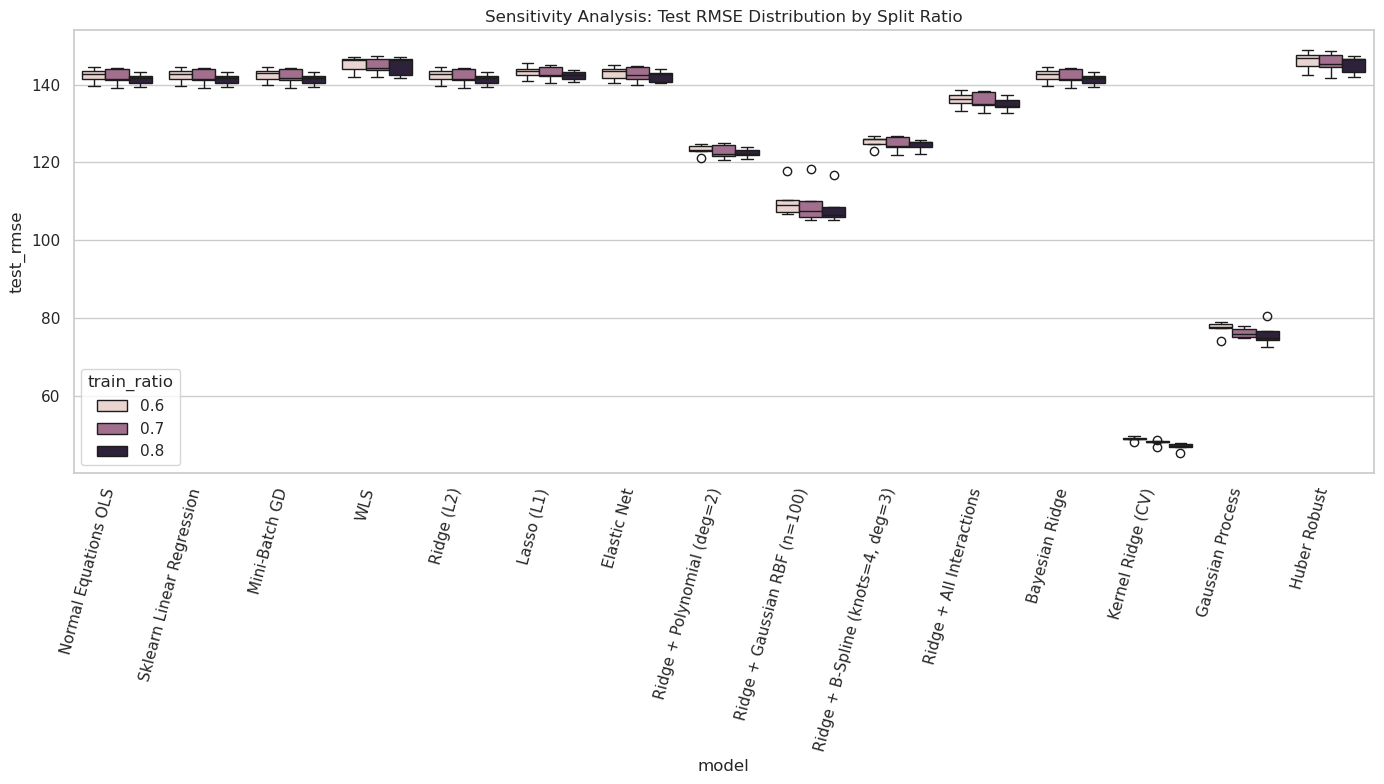

Most stable models (lower CV is better):


,model,mean,std,cv
5,Lasso (L1),142.846274,1.578042,0.011047
12,Ridge + Polynomial (deg=2),122.780046,1.450585,0.011814
6,Mini-Batch GD,141.944389,1.740616,0.012263
1,Elastic Net,142.579668,1.756871,0.012322
0,Bayesian Ridge,141.915926,1.769870,0.012471
8,Ridge (L2),141.931002,1.783726,0.012568
7,Normal Equations OLS,141.941919,1.802138,0.012696
13,Sklearn Linear Regression,141.941919,1.802138,0.012696
10,"Ridge + B-Spline (knots=4, deg=3)",124.794271,1.643303,0.013168
14,WLS,144.912817,2.127435,0.014681


In [ ]:
sensitivity_rows = []
sensitivity_fold_rows = []
sensitivity_split_logs = []
sensitivity_errors = []

for ratio in SPLIT_RATIOS:
    for seed in SPLIT_SEEDS:
        idx = create_split_indices(len(X_full), train_ratio=ratio, seed=seed, val_ratio_in_train=0.2)
        X_tr, y_tr = X_full[idx["train_idx"]], y_full[idx["train_idx"]]
        X_va, y_va = X_full[idx["val_idx"]], y_full[idx["val_idx"]]
        X_te, y_te = X_full[idx["test_idx"]], y_full[idx["test_idx"]]

        res_df, fold_df, errs = evaluate_suite(X_tr, y_tr, X_va, y_va, X_te, y_te, MODEL_NAMES, seed=seed, include_folds=True)

        if len(res_df):
            res_df["experiment"] = "sensitivity"
            res_df["train_ratio"] = ratio
            res_df["seed"] = seed
            sensitivity_rows.append(res_df)

        if len(fold_df):
            fold_df["experiment"] = "sensitivity"
            fold_df["train_ratio"] = ratio
            fold_df["seed"] = seed
            sensitivity_fold_rows.append(fold_df)

        sensitivity_split_logs.append({
            "experiment": "sensitivity",
            "train_ratio": ratio,
            "seed": seed,
            "train_idx": idx["train_idx"].tolist(),
            "val_idx": idx["val_idx"].tolist(),
            "test_idx": idx["test_idx"].tolist(),
        })
        sensitivity_errors.extend([{"train_ratio": ratio, "seed": seed, **e} for e in errs])

sensitivity_df = pd.concat(sensitivity_rows, ignore_index=True) if sensitivity_rows else pd.DataFrame()
sensitivity_fold_df = pd.concat(sensitivity_fold_rows, ignore_index=True) if sensitivity_fold_rows else pd.DataFrame()

sensitivity_df.to_csv(os.path.join(RESULT_DIR, "sensitivity_metrics.csv"), index=False)
sensitivity_fold_df.to_csv(os.path.join(RESULT_DIR, "kfold_metrics.csv"), index=False)
save_json(os.path.join(RESULT_DIR, "split_indices.json"), sensitivity_split_logs)
save_json(os.path.join(RESULT_DIR, "errors_sensitivity.json"), sensitivity_errors)

ok_sens = sensitivity_df[sensitivity_df["status"] == "ok"].copy() if len(sensitivity_df) else pd.DataFrame()
if len(ok_sens):
    plt.figure(figsize=(14, 8))
    sns.boxplot(data=ok_sens, x="model", y="test_rmse", hue="train_ratio")
    plt.title("Sensitivity Analysis: Test RMSE Distribution by Split Ratio")
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.show()

    stability = ok_sens.groupby("model")["test_rmse"].agg(["mean", "std"]).reset_index()
    stability["cv"] = stability["std"] / stability["mean"]
    stability = stability.sort_values("cv")
    print("Most stable models (lower CV is better):")
    display(stability.head(10))

In [10]:
if len(ok_sens):
    stability = ok_sens.groupby("model")["test_rmse"].agg(["mean", "std"]).reset_index()
    stability["cv"] = stability["std"] / stability["mean"]
    stability = stability.sort_values("cv")
    print("Most stable models (FULL)")
    display(stability)

Most stable models (FULL)


,model,mean,std,cv
5,Lasso (L1),142.846274,1.578042,0.011047
12,Ridge + Polynomial (deg=2),122.780046,1.450585,0.011814
6,Mini-Batch GD,141.944389,1.740616,0.012263
1,Elastic Net,142.579668,1.756871,0.012322
0,Bayesian Ridge,141.915926,1.769870,0.012471
8,Ridge (L2),141.931002,1.783726,0.012568
7,Normal Equations OLS,141.941919,1.802138,0.012696
13,Sklearn Linear Regression,141.941919,1.802138,0.012696
10,"Ridge + B-Spline (knots=4, deg=3)",124.794271,1.643303,0.013168
14,WLS,144.912817,2.127435,0.014681


## Noise injection robustness


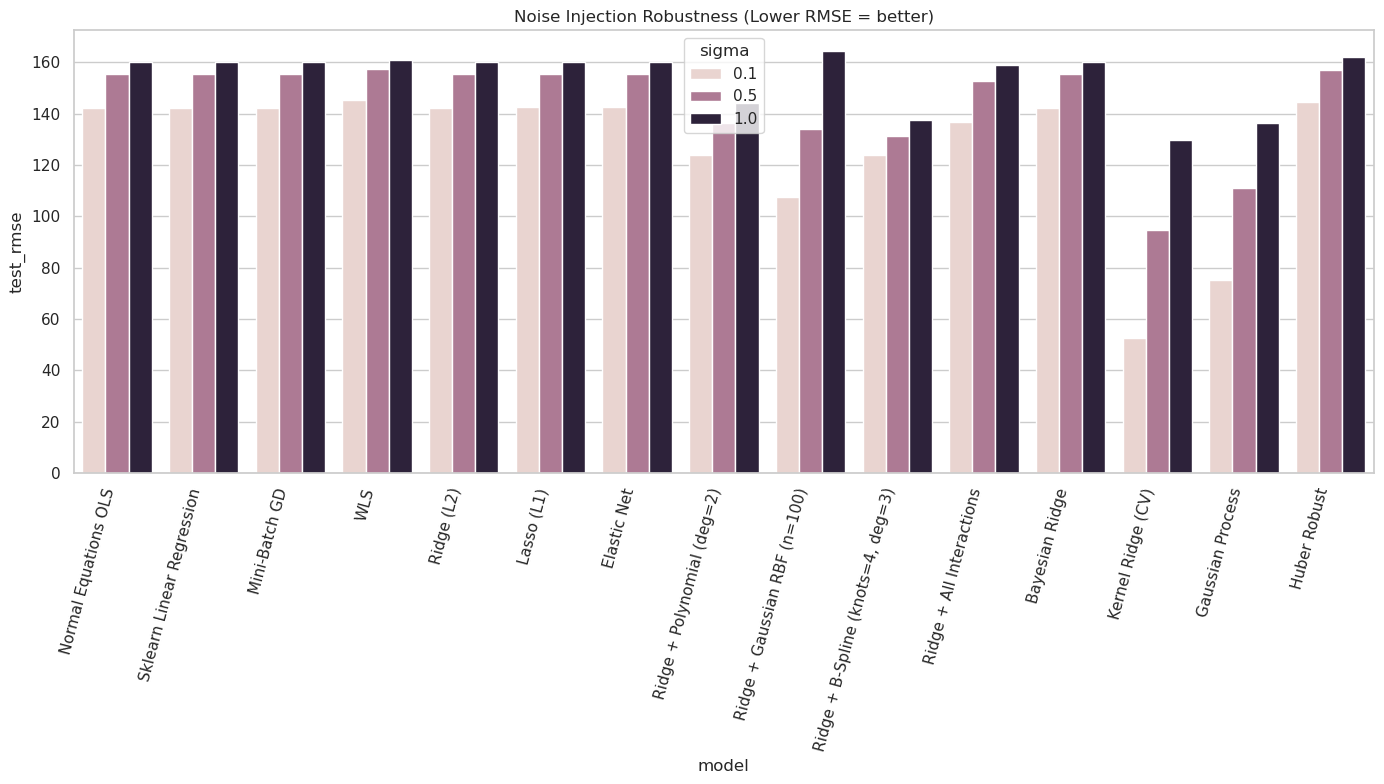

In [6]:
noise_rows = []
noise_errors = []

idx_base = create_split_indices(len(X_full), train_ratio=0.8, seed=GLOBAL_SEED, val_ratio_in_train=0.2)
X_tr0, y_tr0 = X_full[idx_base["train_idx"]], y_full[idx_base["train_idx"]]
X_va0, y_va0 = X_full[idx_base["val_idx"]], y_full[idx_base["val_idx"]]
X_te0, y_te0 = X_full[idx_base["test_idx"]], y_full[idx_base["test_idx"]]

for sigma in NOISE_SIGMAS:
    X_tr = apply_gaussian_noise(X_tr0, sigma=sigma, seed=GLOBAL_SEED)
    X_va = apply_gaussian_noise(X_va0, sigma=sigma, seed=GLOBAL_SEED + 1)
    X_te = apply_gaussian_noise(X_te0, sigma=sigma, seed=GLOBAL_SEED + 2)

    res_df, _, errs = evaluate_suite(X_tr, y_tr0, X_va, y_va0, X_te, y_te0, MODEL_NAMES, seed=GLOBAL_SEED, include_folds=False)
    if len(res_df):
        res_df["experiment"] = "noise"
        res_df["sigma"] = sigma
        noise_rows.append(res_df)
    noise_errors.extend([{"sigma": sigma, **e} for e in errs])

noise_df = pd.concat(noise_rows, ignore_index=True) if noise_rows else pd.DataFrame()
noise_df.to_csv(os.path.join(RESULT_DIR, "noise_metrics.csv"), index=False)
save_json(os.path.join(RESULT_DIR, "errors_noise.json"), noise_errors)

if len(noise_df):
    ok_noise = noise_df[noise_df["status"] == "ok"].copy()
    plt.figure(figsize=(14, 8))
    sns.barplot(data=ok_noise, x="model", y="test_rmse", hue="sigma")
    plt.title("Noise Injection Robustness (Lower RMSE = better)")
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.show()

## Feature corruption + imputation


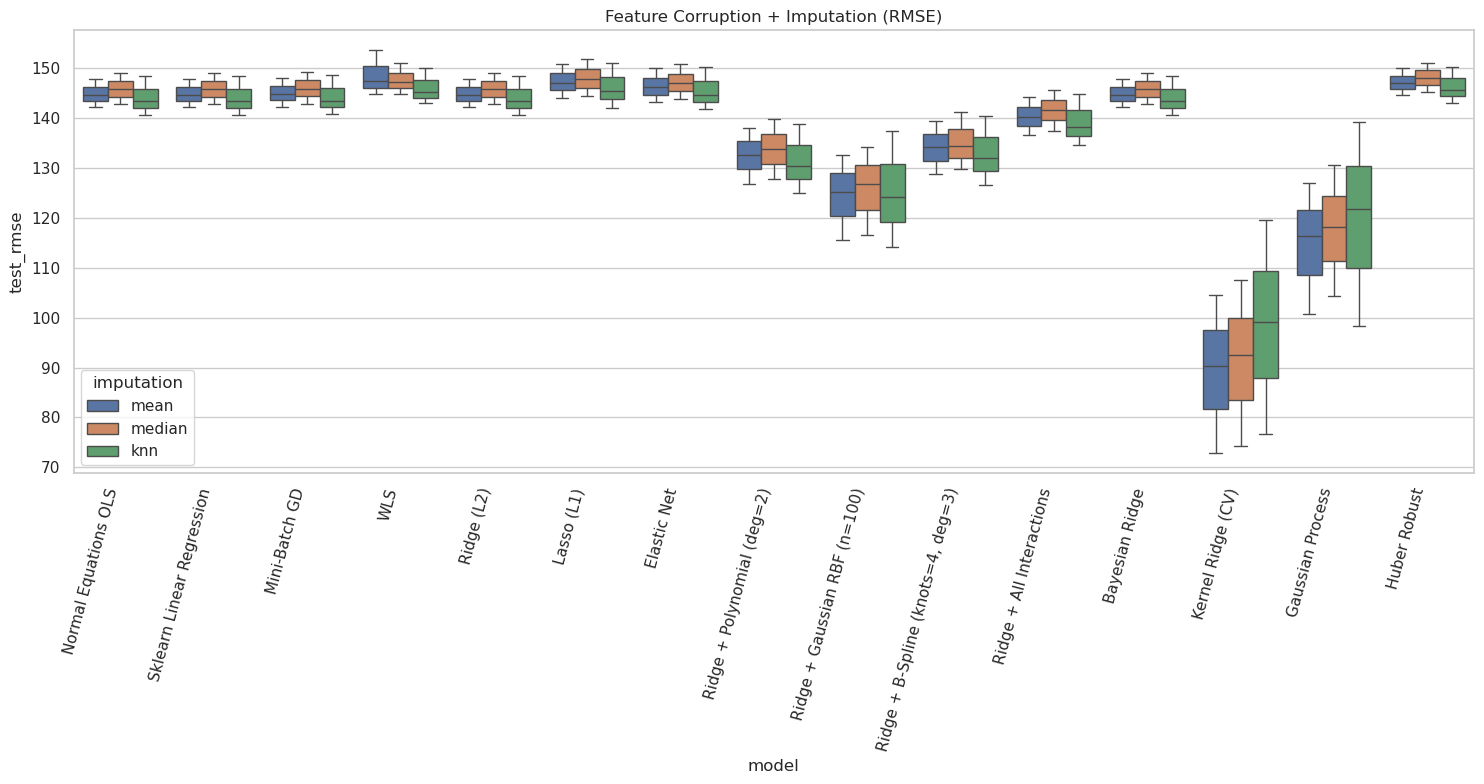

In [7]:
corruption_rows = []
corruption_errors = []

for rate in CORRUPTION_RATES:
    X_tr_nan, _ = corrupt_features(X_tr0, corruption_rate=rate, seed=GLOBAL_SEED)
    X_va_nan, _ = corrupt_features(X_va0, corruption_rate=rate, seed=GLOBAL_SEED + 1)
    X_te_nan, _ = corrupt_features(X_te0, corruption_rate=rate, seed=GLOBAL_SEED + 2)

    for strategy in IMPUTE_STRATEGIES:
        X_tr_imp, X_va_imp = impute_features(X_tr_nan, X_va_nan, strategy=strategy)
        _, X_te_imp = impute_features(X_tr_nan, X_te_nan, strategy=strategy)

        res_df, _, errs = evaluate_suite(
            X_tr_imp, y_tr0, X_va_imp, y_va0, X_te_imp, y_te0, MODEL_NAMES, seed=GLOBAL_SEED, include_folds=False
        )
        if len(res_df):
            res_df["experiment"] = "feature_corruption"
            res_df["corruption_rate"] = rate
            res_df["imputation"] = strategy
            corruption_rows.append(res_df)

        corruption_errors.extend([{"corruption_rate": rate, "imputation": strategy, **e} for e in errs])

corruption_df = pd.concat(corruption_rows, ignore_index=True) if corruption_rows else pd.DataFrame()
corruption_df.to_csv(os.path.join(RESULT_DIR, "feature_corruption_metrics.csv"), index=False)
save_json(os.path.join(RESULT_DIR, "errors_feature_corruption.json"), corruption_errors)

if len(corruption_df):
    ok_corr = corruption_df[corruption_df["status"] == "ok"].copy()
    plt.figure(figsize=(15, 8))
    sns.boxplot(data=ok_corr, x="model", y="test_rmse", hue="imputation")
    plt.title("Feature Corruption + Imputation (RMSE)")
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.show()

## Convergence curves for iterative algorithms


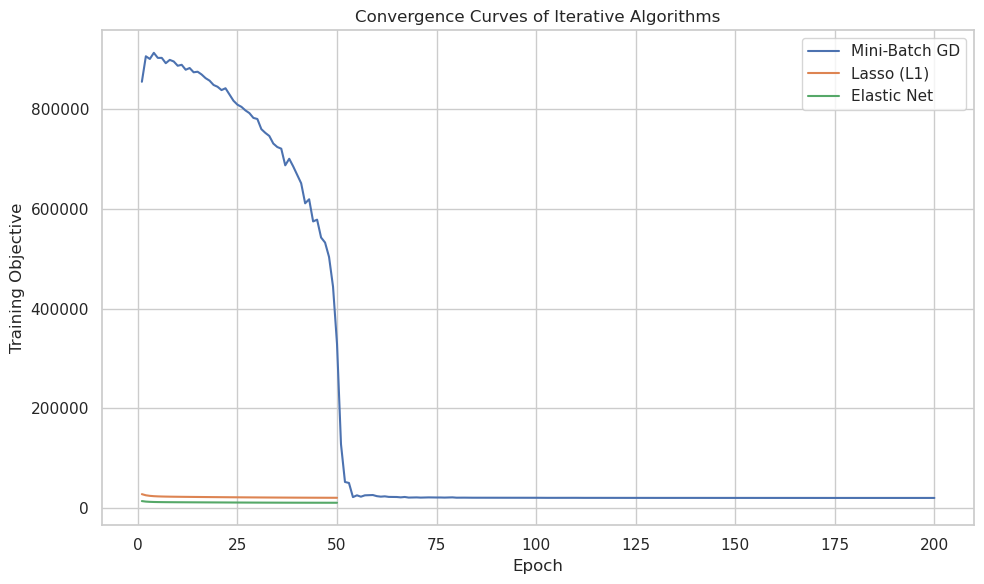

,model,train_time_sec,test_time_sec,peak_memory_mb
3,Huber Robust,0.329732,0.000259,1.620321
13,Sklearn Linear Regression,0.003093,0.000225,2.068518
7,Normal Equations OLS,0.001164,0.000107,2.133471
1,Elastic Net,2.303389,0.000128,2.251724
14,WLS,0.003014,0.000105,2.372327
5,Lasso (L1),1.832431,0.000141,2.430970
0,Bayesian Ridge,0.007282,0.000292,2.934330
8,Ridge (L2),0.081073,0.000105,3.063715
6,Mini-Batch GD,0.532551,0.000123,3.325570
10,"Ridge + B-Spline (knots=4, deg=3)",0.032960,0.000381,10.810759


In [8]:
iterative_models = ["Mini-Batch GD", "Lasso (L1)", "Elastic Net"]
convergence_payload = []

for m in iterative_models:
    _, info, err = train_and_predict(m, X_tr0, y_tr0, X_va0, seed=GLOBAL_SEED, return_curve=True)
    if err is None and info.get("convergence") is not None:
        convergence_payload.append({"model": m, "loss_curve": info["convergence"]})

save_json(os.path.join(RESULT_DIR, "convergence_curves.json"), convergence_payload)

if len(convergence_payload):
    plt.figure(figsize=(10, 6))
    for item in convergence_payload:
        losses = item["loss_curve"]
        plt.plot(range(1, len(losses) + 1), losses, label=item["model"])
    plt.xlabel("Epoch")
    plt.ylabel("Training Objective")
    plt.title("Convergence Curves of Iterative Algorithms")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Runtime/Memory summary across all experiments
all_frames = [df for df in [sensitivity_df, noise_df, corruption_df] if len(df)]
if all_frames:
    all_metrics = pd.concat(all_frames, ignore_index=True)
    ok_metrics = all_metrics[all_metrics["status"] == "ok"].copy()
    runtime_summary = ok_metrics.groupby("model")[["train_time_sec", "test_time_sec", "peak_memory_mb"]].mean().reset_index()
    runtime_summary = runtime_summary.sort_values(["peak_memory_mb", "train_time_sec"])
    runtime_summary.to_csv(os.path.join(RESULT_DIR, "runtime_memory_summary.csv"), index=False)
    display(runtime_summary.head(20))